In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

In [60]:
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='2010-01-01',
                          end_datetime='2010-07-01')

ds1

<xarray.Dataset> Size: 12GB
Dimensions:                (time_counter: 36, y: 1206, x: 1440, axis_nbounds: 2)
Coordinates:
    nav_lon                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lat                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 288B 2010-01-03T12:0...
    time_centered          (time_counter) datetime64[ns] 288B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/50)
    evs                    (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfls                   (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    berg_latent_heat_flux  (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfds                   (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfns                   (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                     ...
    tossq_con              (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    sowaflup               (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    time_counter_bounds    (time_counter, axis_nbounds) datetime64[ns] 576B dask.array<chunksize=(1, 2), meta=np.ndarray>
    tos_con                (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 250MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_5d_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-22 08:10:47 GMT
    uuid:         912ed051-fc3b-47ec-a958-2563cca7642e

In [61]:
random_point = ds1['tos_con'].sel(y = 950, x = 1050)
random_point

<xarray.DataArray 'tos_con' (time_counter: 36)> Size: 144B
dask.array<getitem, shape=(36,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    nav_lon        float64 8B dask.array<chunksize=(), meta=np.ndarray>
    nav_lat        float64 8B dask.array<chunksize=(), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 288B 2010-01-03T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 288B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)

In [62]:
df = random_point.to_dataframe()
df.head(37)

,nav_lon,nav_lat,time_centered,tos_con
time_counter,,,,
2010-01-03 12:00:00,-24.237223,56.236538,2010-01-03 12:00:00,9.358837
2010-01-08 12:00:00,-24.237223,56.236538,2010-01-08 12:00:00,9.360342
2010-01-13 12:00:00,-24.237223,56.236538,2010-01-13 12:00:00,9.280033
2010-01-18 12:00:00,-24.237223,56.236538,2010-01-18 12:00:00,9.137540
2010-01-23 12:00:00,-24.237223,56.236538,2010-01-23 12:00:00,8.994410
2010-01-28 12:00:00,-24.237223,56.236538,2010-01-28 12:00:00,8.885824
2010-02-02 12:00:00,-24.237223,56.236538,2010-02-02 12:00:00,9.023870
2010-02-07 12:00:00,-24.237223,56.236538,2010-02-07 12:00:00,9.116411
2010-02-12 12:00:00,-24.237223,56.236538,2010-02-12 12:00:00,9.088495


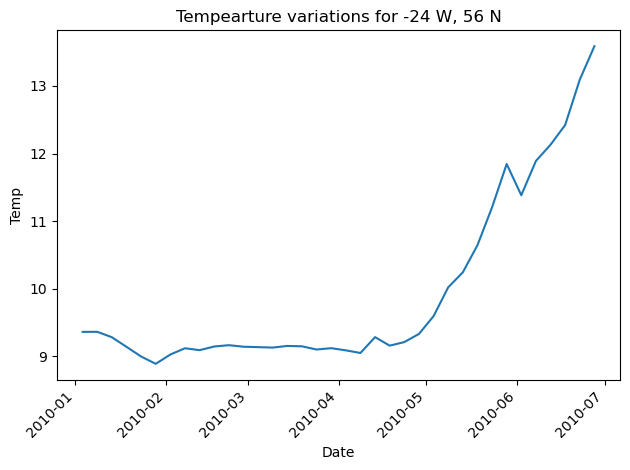

In [63]:
fig, ax = plt.subplots()
ax.plot(df['time_centered'], df['tos_con'])
ax.set_xlabel('Date')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for -24 W, 56 N')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()